In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## a) Testsignale erzeugen

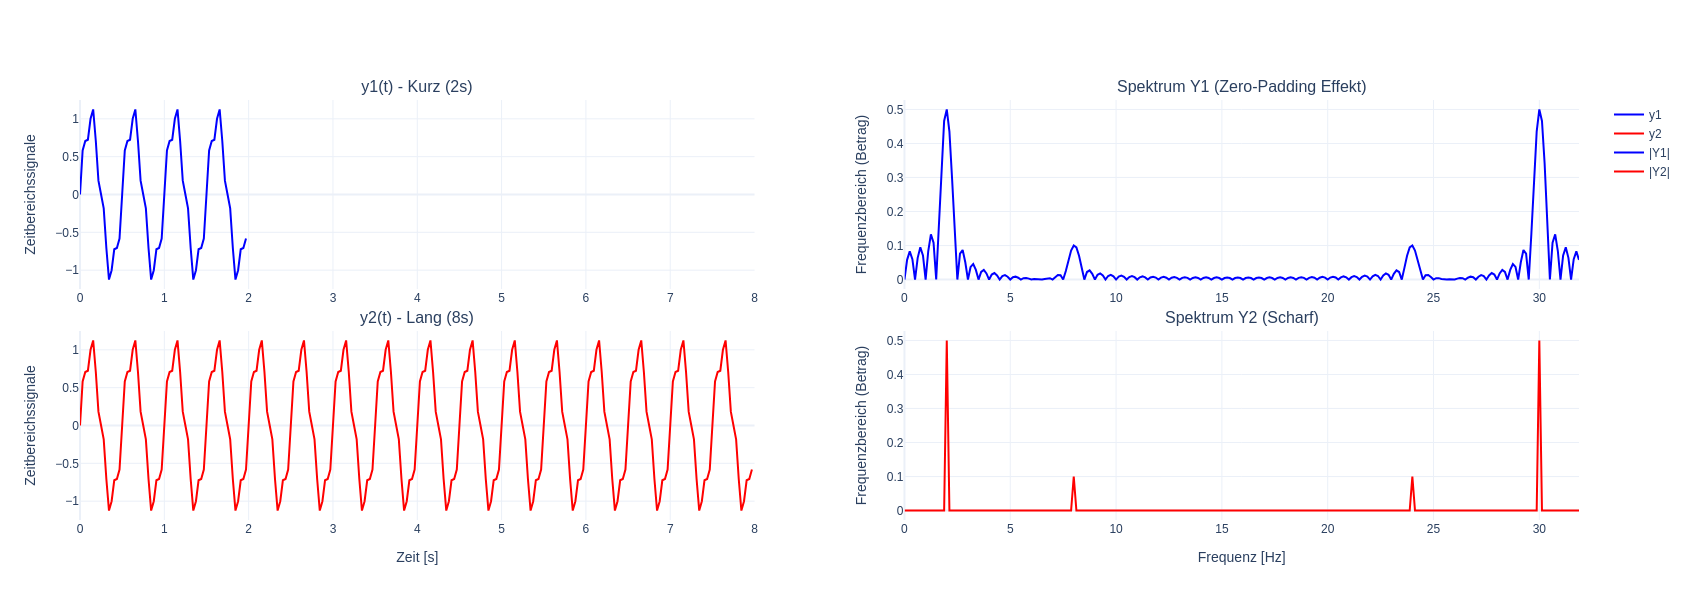

In [34]:
fs = 32.0  # Sampling Frequenz
f1 = 2.0
f2 = 8.0

# Zeitvektoren
# MATLAB: 0:1/Fs:2-1/Fs -> Python: np.arange(start, stop, step)
# arange exkludiert den Stop-Wert, das passt also perfekt.
t1 = np.arange(0, 2, 1 / fs)  # 2 Sekunden (64 Samples)
t2 = np.arange(0, 8, 1 / fs)  # 8 Sekunden (256 Samples)

# Signale: Mischung aus zwei Sinus-Wellen
y1 = np.sin(2 * np.pi * t1 * 2) + 0.2 * np.sin(2 * np.pi * t1 * 8)
y2 = np.sin(2 * np.pi * t2 * 2) + 0.2 * np.sin(2 * np.pi * t2 * 8)

# FFT Parameter
n_fft = 256

# FFT Berechnung
# Hinweis: Matlab teilt durch numel(y), also die Signallänge, nicht die FFT-Länge.
# fft(y, n_fft) füllt automatisch mit Nullen auf, wenn y kürzer als n_fft ist (Zero-Padding).
y1_fft = np.fft.fft(y1, n_fft) / len(y1)
y2_fft = np.fft.fft(y2, n_fft) / len(y2)

# Frequenzachse
delta_f = fs / n_fft
freq_axis = np.arange(0, fs, delta_f)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "y1(t) - Kurz (2s)",
        "Spektrum Y1 (Zero-Padding Effekt)",
        "y2(t) - Lang (8s)",
        "Spektrum Y2 (Scharf)",
    ),
    # shared_xaxes=True,
    vertical_spacing=0.1,
)

# --- Visualisierung Zeitbereich (Vergleich y1 vs y2) ---

fig.add_trace(go.Scatter(x=t1, y=y1, name="y1", line=dict(color="blue")), row=1, col=1)
fig.add_trace(go.Scatter(x=t2, y=y2, name="y2", line=dict(color="red")), row=2, col=1)

fig.update_xaxes(range=[0, 8], col=1)
fig.update_xaxes(title_text="Zeit [s]", col=1, row=2)
fig.update_yaxes(title_text="Zeitbereichssignale", col=1)


# --- Visualisierung Frequenzbereich (Vergleich Y1 vs Y2) ---

# Wir plotten den Betrag (Magnitude)
fig.add_trace(
    go.Scatter(x=freq_axis, y=np.abs(y1_fft), name="|Y1|", line=dict(color="blue")),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(x=freq_axis, y=np.abs(y2_fft), name="|Y2|", line=dict(color="red")),
    row=2,
    col=2,
)

fig.update_layout(height=600, template="plotly_white")
fig.update_xaxes(title_text="Frequenz [Hz]", col=2, row=2)
fig.update_yaxes(title_text="Frequenzbereich (Betrag)", col=2)
fig.show()

## b) Fenstersignal (Blackman)

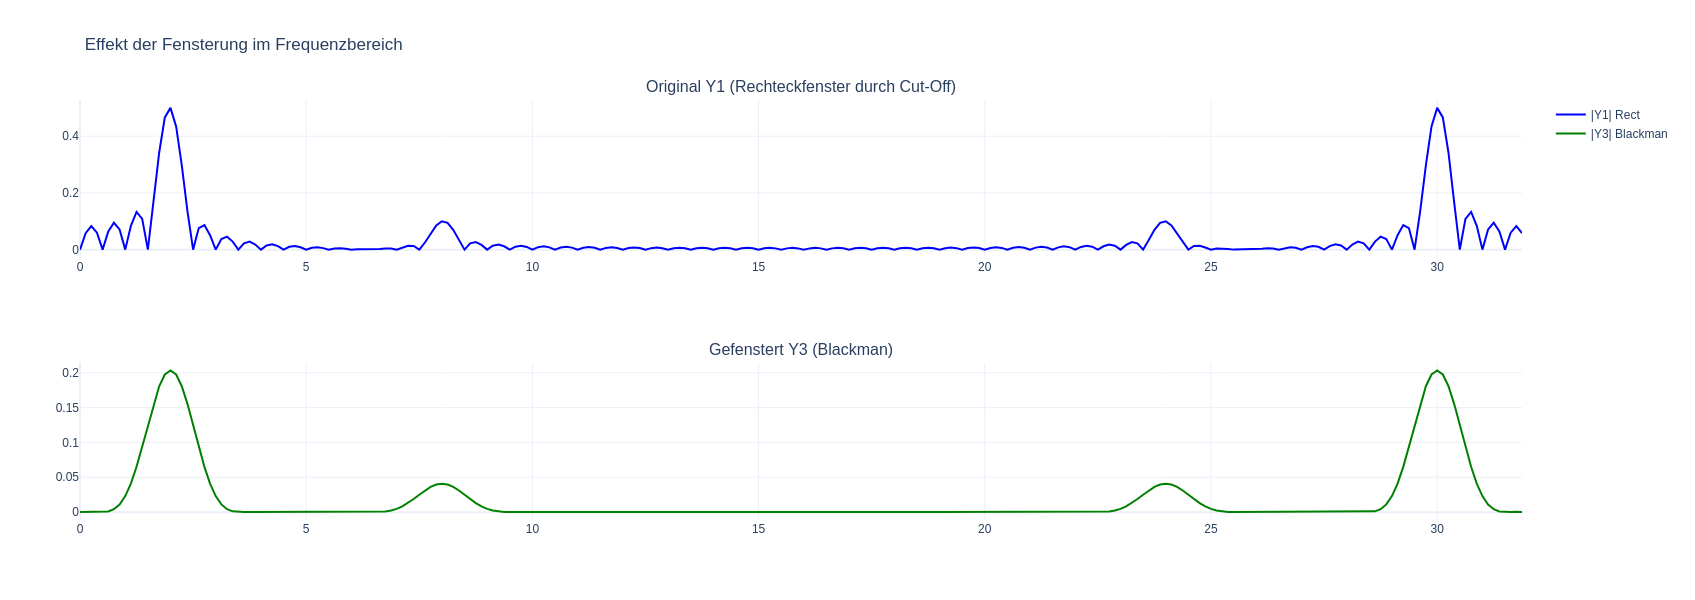

In [35]:
# Erzeuge Fenstersignal manuell
n_half = len(y1) // 2  # 32

n_idx = np.arange(1 - n_half, n_half + 1)

# Blackman Formel (Manuell implementiert wie im Skript)
w_blackman = (
    0.42
    + 0.5 * np.cos(n_idx * np.pi / (n_half - 1))
    + 0.08 * np.cos(2 * n_idx * np.pi / (n_half - 1))
)

# Fensterung anwenden (Element-weise Multiplikation)
# Achtung: w_blackman muss gleiche Länge wie y1 haben (64)
# np.arange(1-32, 33) erzeugt 64 Werte -> Passt.
y3 = y1 * w_blackman

# FFT des gefensterten Signals
y3_fft = np.fft.fft(y3, n_fft) / len(y3)


# --- Vergleich der Spektren (Y1 vs Y3) ---
fig_comp = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        "Original Y1 (Rechteckfenster durch Cut-Off)",
        "Gefenstert Y3 (Blackman)",
    ),
)

fig_comp.add_trace(
    go.Scatter(
        x=freq_axis, y=np.abs(y1_fft), name="|Y1| Rect", line=dict(color="blue")
    ),
    row=1,
    col=1,
)
fig_comp.add_trace(
    go.Scatter(
        x=freq_axis, y=np.abs(y3_fft), name="|Y3| Blackman", line=dict(color="green")
    ),
    row=2,
    col=1,
)

fig_comp.update_layout(
    height=600,
    title="Effekt der Fensterung im Frequenzbereich",
    template="plotly_white",
)
fig_comp.show()

## Verständnis Zeitbereich (Zero Padding visualisieren)

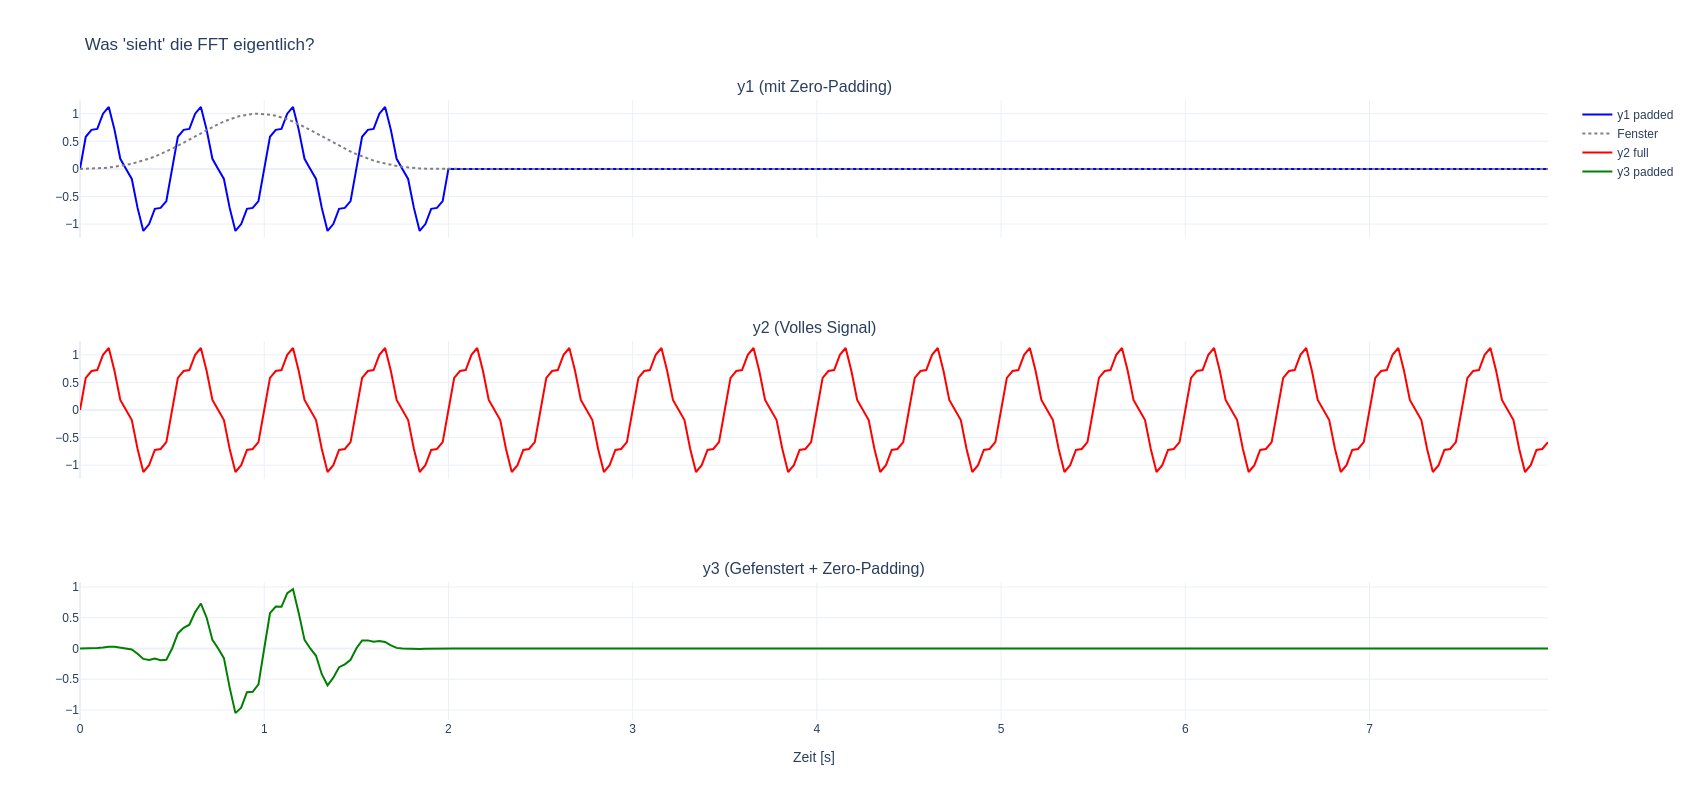

In [4]:
# Wir bauen die Signale so nach, wie die FFT sie "sieht" (mit Nullen aufgefüllt)

zeros_padding = np.zeros(256 - len(y1))

y1_padded = np.concatenate([y1, zeros_padding])
w_padded = np.concatenate(
    [w_blackman, zeros_padding]
)  # Nur zur Deko, um das Fenster zu zeigen
y2_full = y2  # Ist schon 256 lang
y3_padded = np.concatenate([y3, zeros_padding])

t_padded = np.arange(0, 256) * (1 / fs)  # Zeitachse für das volle FFT-Fenster

fig_pad = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "y1 (mit Zero-Padding)",
        "y2 (Volles Signal)",
        "y3 (Gefenstert + Zero-Padding)",
    ),
)

# Subplot 1: y1 + Fenster-Hüllkurve
fig_pad.add_trace(
    go.Scatter(x=t_padded, y=y1_padded, name="y1 padded", line=dict(color="blue")),
    row=1,
    col=1,
)
fig_pad.add_trace(
    go.Scatter(
        x=t_padded, y=w_padded, name="Fenster", line=dict(color="gray", dash="dot")
    ),
    row=1,
    col=1,
)

# Subplot 2: y2
fig_pad.add_trace(
    go.Scatter(x=t_padded, y=y2_full, name="y2 full", line=dict(color="red")),
    row=2,
    col=1,
)

# Subplot 3: y3
fig_pad.add_trace(
    go.Scatter(x=t_padded, y=y3_padded, name="y3 padded", line=dict(color="green")),
    row=3,
    col=1,
)

fig_pad.update_layout(
    height=800, title="Was 'sieht' die FFT eigentlich?", template="plotly_white"
)
fig_pad.update_xaxes(title_text="Zeit [s]", row=3, col=1)
fig_pad.show()